# 06 — Product Trend Prediction Model (Neural Network)
Train a Neural Network (MLP) classification model to predict whether a product will trend in a specific region.
Output: `model_trending_nn.pkl`, `scaler_trending.pkl`, `encoders_trending_nn.pkl`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, roc_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style='darkgrid')
print('✅ Library is Ready')

✅ Library is Ready


## 1. Load & Prepare Data

In [3]:
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')
df['profit_margin'] = df['profit'] / df['sales']
df['revenue_per_unit'] = df['sales'] / df['quantity']

print(f'Total data: {len(df):,} line')
print(f"\nDistribution target (is_trending):")
print(df['is_trending'].value_counts())
print(f"\nBalance ratio: {df['is_trending'].mean()*100:.1f}% trending")

Total data: 5,000 line

Distribution target (is_trending):
is_trending
0    2997
1    2003
Name: count, dtype: int64

Balance ratio: 40.1% trending


## 2. Trend-Specific EDA

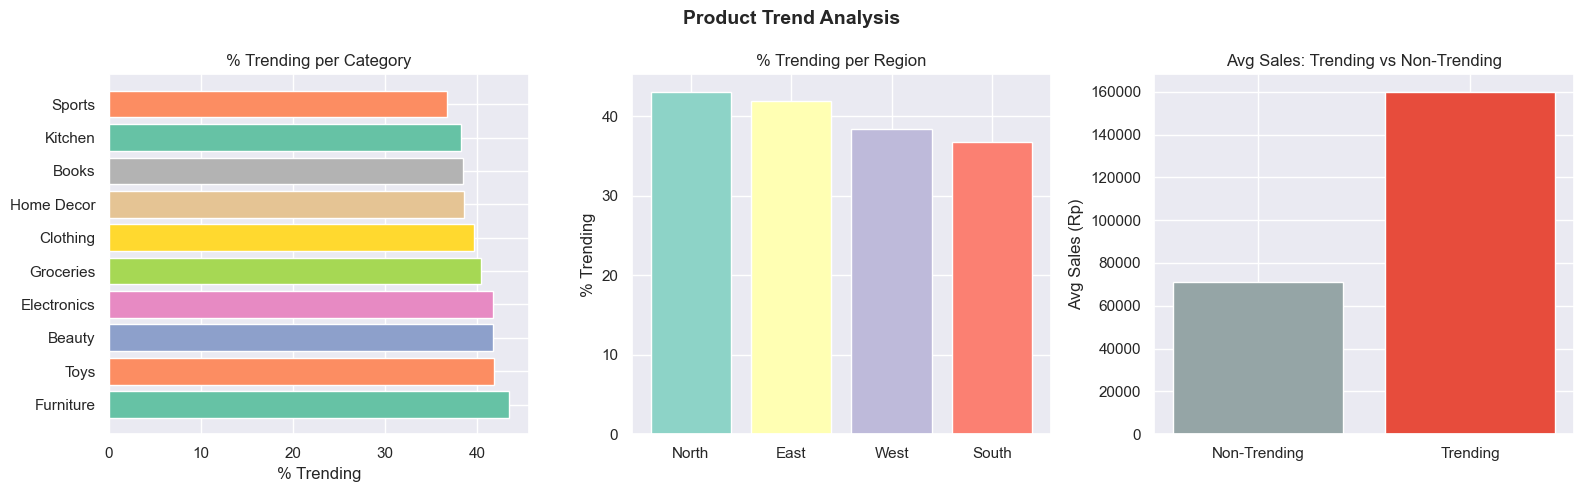

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Trending per Category
trend_cat = df.groupby('category')['is_trending'].mean().sort_values(ascending=False)
axes[0].barh(trend_cat.index, trend_cat.values * 100, color=sns.color_palette('Set2'))
axes[0].set_xlabel('% Trending')
axes[0].set_title('% Trending per Category')

# Trending per Region
trend_reg = df.groupby('region')['is_trending'].mean().sort_values(ascending=False)
axes[1].bar(trend_reg.index, trend_reg.values * 100, color=sns.color_palette('Set3'))
axes[1].set_ylabel('% Trending')
axes[1].set_title('% Trending per Region')

# Avg sales: trending vs not trending
comp = df.groupby('is_trending')['sales'].mean()
axes[2].bar(['Non-Trending', 'Trending'], comp.values, color=['#95a5a6','#e74c3c'])
axes[2].set_ylabel('Avg Sales (Rp)')
axes[2].set_title('Avg Sales: Trending vs Non-Trending')

plt.suptitle('Product Trend Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Encoding & Feature Selection

In [5]:
le_dict = {}
cat_cols = ['region', 'city', 'category', 'sub_category', 'payment_mode']
df_enc = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'  ✅ {col}: {le.classes_.tolist()}')

FEATURES = [
    'quantity', 'unit_price', 'discount', 'month', 'year',
    'profit_margin', 'revenue_per_unit',
    'region_enc', 'city_enc', 'category_enc', 'sub_category_enc', 'payment_mode_enc'
]

X = df_enc[FEATURES]
y = df_enc['is_trending']
print(f'\nNumber of features: {len(FEATURES)}')
print(f'Shape X: {X.shape}, y: {y.shape}')

  ✅ region: ['East', 'North', 'South', 'West']
  ✅ city: ['Ahmedabad', 'Amritsar', 'Bangalore', 'Bhubaneswar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Goa', 'Guwahati', 'Hyderabad', 'Jaipur', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Pune', 'Ranchi', 'Surat', 'Thiruvananthapuram']
  ✅ category: ['Beauty', 'Books', 'Clothing', 'Electronics', 'Furniture', 'Groceries', 'Home Decor', 'Kitchen', 'Sports', 'Toys']
  ✅ sub_category: ['Accessories', 'Action Figure', 'Bed', 'Biography', 'Board Game', 'Cabinet', 'Camera', 'Chair', 'Clock', 'Comics', 'Cookware Set', 'Cricket Bat', 'Cushion', 'Doll', 'Dumbbells', 'Face Cream', 'Fiction', 'Football', 'Foundation', 'Headphones', 'Juicer', 'Kids Wear', 'Lamp', 'Laptop', 'Lipstick', "Men's Wear", 'Microwave', 'Mixer Grinder', 'Mobile', 'Non-Fiction', 'Oil', 'Perfume', 'Puzzle', 'RC Car', 'Refrigerator', 'Rice', 'Shampoo', 'Shoes', 'Smartwatch', 'Sofa', 'Spices', 'Sugar', 'Table', 'Tennis Racket', 'Textbook', 'Vase', 'Wall Art', 'Wheat', "Wome

## 4. Split Data & Feature Scaling
> ⚠️ MLP requires feature scaling — StandardScaler is applied after split to prevent data leakage.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (fit only on train to avoid leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} line')
print(f'Test : {X_test.shape[0]:,} line')
print(f'Rasio trending in train: {y_train.mean()*100:.1f}%')
print(f'Rasio trending in test : {y_test.mean()*100:.1f}%')

Train: 4,000 line
Test : 1,000 line
Rasio trending in train: 40.1%
Rasio trending in test : 40.1%


## 5. Training & Model Comparison

In [7]:
models = {
    'MLP Neural Network'  : MLPClassifier(
                                hidden_layer_sizes=(128, 64, 32),
                                activation='relu',
                                solver='adam',
                                max_iter=500,
                                early_stopping=True,
                                random_state=42
                            ),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if 'MLP' in name else X_train
    X_te = X_test_sc  if 'MLP' in name else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    auc    = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    cv     = cross_val_score(model, X_train_sc if 'MLP' in name else X_train,
                             y_train, cv=5, scoring='roc_auc').mean()
    results[name] = {'model': model, 'y_pred': y_pred, 'auc': auc, 'cv': cv}
    print(f'[{name}]  AUC-Test: {auc:.4f}  |  CV-AUC: {cv:.4f}')

[MLP Neural Network]  AUC-Test: 1.0000  |  CV-AUC: 1.0000
[Gradient Boosting]  AUC-Test: 1.0000  |  CV-AUC: 1.0000
[Random Forest]  AUC-Test: 1.0000  |  CV-AUC: 1.0000


## 6. Best Model Evaluation

In [8]:
best_name   = max(results, key=lambda x: results[x]['auc'])
best_model  = results[best_name]['model']
y_pred_best = results[best_name]['y_pred']

print(f'🏆 Best Model: {best_name}')
print(f'   AUC-ROC: {results[best_name]["auc"]:.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Non-Trending', 'Trending']))

🏆 Best Model: MLP Neural Network
   AUC-ROC: 1.0000

              precision    recall  f1-score   support

Non-Trending       1.00      1.00      1.00       599
    Trending       1.00      1.00      1.00       401

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



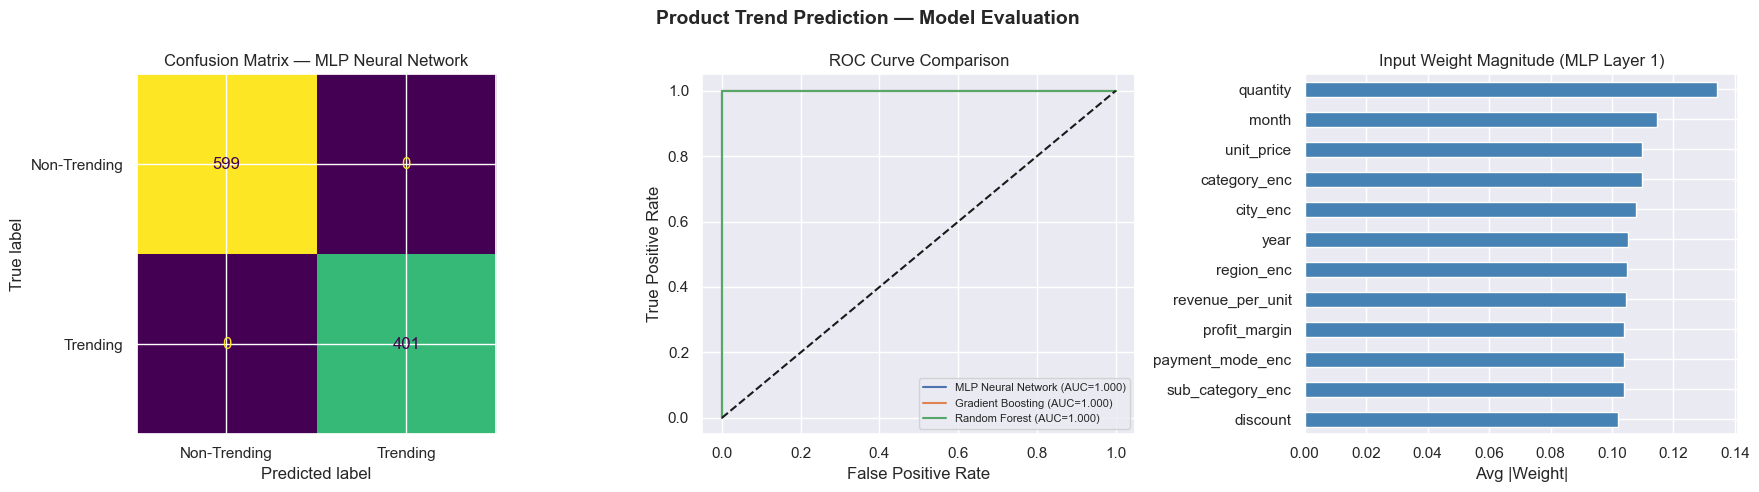

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Non-Trending', 'Trending']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')

# ROC Curve (all models)
for name, res in results.items():
    X_te = X_test_sc if 'MLP' in name else X_test
    fpr, tpr, _ = roc_curve(y_test, res['model'].predict_proba(X_te)[:, 1])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend(fontsize=8)

# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    fi.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Feature Importance')
    axes[2].set_xlabel('Importance Score')
elif hasattr(best_model, 'coefs_'):
    importance = np.abs(best_model.coefs_[0]).mean(axis=1)
    fi = pd.Series(importance, index=FEATURES).sort_values()
    fi.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Input Weight Magnitude (MLP Layer 1)')
    axes[2].set_xlabel('Avg |Weight|')

plt.suptitle('Product Trend Prediction — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Save Models, Scaler & Encoders

In [10]:
with open('../Notebooks/model_trending_nn.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'features': FEATURES}, f)

with open('../Notebooks/scaler_trending.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../Notebooks/encoders_trending_nn.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print('✅ Saved:')
print('   📦 model_trending_nn.pkl')
print('   📦 scaler_trending.pkl')
print('   📦 encoders_trending_nn.pkl')

✅ Saved:
   📦 model_trending_nn.pkl
   📦 scaler_trending.pkl
   📦 encoders_trending_nn.pkl
